In [ ]:
# import libraries

In [ ]:
from pprint import PrettyPrinter
import pandas as pd
from pymongo import MongoClient

In [ ]:
pp = PrettyPrinter(indent=2)

In [ ]:
# connect to MongoDB
client = MongoClient("mongodb://127.0.0.1:27017")
# Assign database
db = client["air-quality"]

In [ ]:
# Assign collection
pp.pprint(list(db.list_collection_names()))

['lagos', 'dar-es-salaam', 'nairobi']


In [ ]:
dar = db["dar-es-salaam"]

In [ ]:
dar.count_documents({})

233262

In [ ]:
resutlt = dar.find_one({})

In [ ]:
pp.pprint(resutlt)

{ '_id': ObjectId('6525d778f44bfedd842c72d8'),
  'metadata': "{'lat': -6.818, 'lon': 39.285, 'measurement': 'temperature', "
              "'sensor_id': 34, 'sensor_type': 'DHT22', 'site': 11}",
  'temperature': 30.1,
  'timestamp': '2018-01-01 00:00:48.041'}


In [ ]:
dar.distinct("metadata.site")

[]

In [ ]:
# covert data from string to dict error while loading data into MongoDB
import ast
from pymongo import UpdateOne

batch_size = 1000
operations = []

for i, doc in enumerate(dar.find()):
    if isinstance(doc['metadata'], str):
        operations.append(
            UpdateOne(
                {"_id": doc["_id"]},
                {"$set": {"metadata": ast.literal_eval(doc["metadata"])}}
            )
        )
    # Execute in batches
    if len(operations) == batch_size:
        dar.bulk_write(operations)
        operations = []
        print(f"{i+1} documents processed")

# Execute remaining operations
if operations:
    dar.bulk_write(operations)
    print(f"{i+1} documents processed")

1000 documents processed
2000 documents processed
3000 documents processed
4000 documents processed
5000 documents processed
6000 documents processed
7000 documents processed
8000 documents processed
9000 documents processed
10000 documents processed
11000 documents processed
12000 documents processed
13000 documents processed
14000 documents processed
15000 documents processed
16000 documents processed
17000 documents processed
18000 documents processed
19000 documents processed
20000 documents processed
21000 documents processed
22000 documents processed
23000 documents processed
24000 documents processed
25000 documents processed
26000 documents processed
27000 documents processed
28000 documents processed
29000 documents processed
30000 documents processed
31000 documents processed
32000 documents processed
33000 documents processed
34000 documents processed
35000 documents processed
36000 documents processed
37000 documents processed
38000 documents processed
39000 documents proce

In [ ]:
pp.pprint(resutlt)

{ '_id': ObjectId('6525d778f44bfedd842c72d8'),
  'metadata': "{'lat': -6.818, 'lon': 39.285, 'measurement': 'temperature', "
              "'sensor_id': 34, 'sensor_type': 'DHT22', 'site': 11}",
  'temperature': 30.1,
  'timestamp': '2018-01-01 00:00:48.041'}


In [ ]:
sites = dar.distinct("metadata.site")
sites

[11, 23]

In [ ]:
# Aggregation Framework
# count number of documents per site
result = dar.aggregate([
    {
        "$group": {
            "_id": "$metadata.site",
            "count": {"$sum": 1}
        }
    }
])
readings_per_site = list(result)
readings_per_site

[{'_id': 23, 'count': 60020}, {'_id': 11, 'count': 173242}]

In [ ]:
dar.distinct("metadata.measurement")

['P1', 'P2', 'humidity', 'temperature']

In [ ]:
# IMPORT
# retrieve the PM 2.5 readings from site 29
# limit your results to 3 records only
# use the projection argument to limit the results to the "P2" and "timestamp" keys only
result = dar.find(
    {"metadata.measurement": 11, "metadata.measurement": "P2"},
)
pp.pprint(result.next())

{ 'P2': 9.27,
  '_id': ObjectId('6525d77bf44bfedd842e20ff'),
  'metadata': { 'lat': -6.818,
                'lon': 39.285,
                'measurement': 'P2',
                'sensor_id': 29,
                'sensor_type': 'SDS011',
                'site': 11},
  'timestamp': '2018-01-01 00:00:04.053'}


In [ ]:
# Change Projection
result = dar.find({"metadata.measurement": "P2"},
    projection={"P2": 1, "timestamp": 1, "_id": 0})

pp.pprint(result.next())

{'P2': 9.27, 'timestamp': '2018-01-01 00:00:04.053'}


In [ ]:
# Wrangling Function
def wrangle(collection):
    result = collection.find({"metadata.measurement": "P2"},
    projection={"P2": 1, "timestamp": 1, "_id": 0})

    # Read data into DataFrame
    df = pd.DataFrame(list(result)).set_index("timestamp")
    
    
    return df
# call wrangle function
df = wrangle(dar)
print(df.shape)
df.head()

(78127, 1)


,P2
timestamp,
2018-01-01 00:00:04.053,9.27
2018-01-01 00:02:33.847,8.17
2018-01-01 00:05:03.874,9.70
2018-01-01 00:07:33.675,10.10
2018-01-01 00:10:03.888,9.65


In [ ]:
# Wrangling Function
def wrangle(collection):
    result = collection.find({"metadata.measurement": "P2"},
    projection={"P2": 1, "timestamp": 1, "_id": 0})

    df = pd.DataFrame(result)

    # Convert timestamp column to datetime
    df["timestamp"] = pd.to_datetime(df["timestamp"], errors="coerce")

    # Set as index
    df = df.set_index("timestamp")

    # If timezone-naive → localize
    if df.index.tz is None:
        df.index = df.index.tz_localize("UTC")

    
    return df
# call wrangle function
df = wrangle(dar)
print(df.shape)
df.head()

(78127, 1)


,P2
timestamp,
2018-01-01 00:00:04.053000+00:00,9.27
2018-01-01 00:02:33.847000+00:00,8.17
2018-01-01 00:05:03.874000+00:00,9.70
2018-01-01 00:07:33.675000+00:00,10.10
2018-01-01 00:10:03.888000+00:00,9.65


In [ ]:
# Wrangling Function
def wrangle(collection):
    result = collection.find({"metadata.measurement": "P2"},
    projection={"P2": 1, "timestamp": 1, "_id": 0})

    df = pd.DataFrame(result)

    # Convert timestamp column to datetime
    df["timestamp"] = pd.to_datetime(df["timestamp"], errors="coerce")

    # Set as index
    df = df.set_index("timestamp")

    # If timezone-naive → localize
    if df.index.tz is None:
        df.index = df.index.tz_localize("UTC")
    
    # localised timezone
    df.index = df.index.tz_convert("UTC").tz_convert("Africa/Dar_es_Salaam")
    

    
    return df
# call wrangle function
df = wrangle(dar)
print(df.shape)
df.head()

(78127, 1)


,P2
timestamp,
2018-01-01 03:00:04.053000+03:00,9.27
2018-01-01 03:02:33.847000+03:00,8.17
2018-01-01 03:05:03.874000+03:00,9.70
2018-01-01 03:07:33.675000+03:00,10.10
2018-01-01 03:10:03.888000+03:00,9.65


In [ ]:
# Wrangling Function
def wrangle(collection):
    result = collection.find({"metadata.measurement": "P2"},
    projection={"P2": 1, "timestamp": 1, "_id": 0})

    df = pd.DataFrame(result)

    # Convert timestamp column to datetime
    df["timestamp"] = pd.to_datetime(df["timestamp"], errors="coerce")

    # Set as index
    df = df.set_index("timestamp")

    # If timezone-naive → localize
    if df.index.tz is None:
        df.index = df.index.tz_localize("UTC")
    
    # localised timezone
    df.index = df.index.tz_convert("UTC").tz_convert("Africa/Dar_es_Salaam")
    
    # Remove outliers
    df = df[df["P2"] < 100]
    
    
    return df
# call wrangle function
df = wrangle(dar)
print(df.shape)
df.head()

(78125, 1)


,P2
timestamp,
2018-01-01 03:00:04.053000+03:00,9.27
2018-01-01 03:02:33.847000+03:00,8.17
2018-01-01 03:05:03.874000+03:00,9.70
2018-01-01 03:07:33.675000+03:00,10.10
2018-01-01 03:10:03.888000+03:00,9.65


In [ ]:
df["P2"].resample("H").mean().isnull().sum()

<ipython-input-35-e96acc169225>:1: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  df["P2"].resample("H").mean().isnull().sum()


np.int64(3901)

In [ ]:
# Wrangling Function
def wrangle(collection):
    result = collection.find({"metadata.measurement": "P2"},
    projection={"P2": 1, "timestamp": 1, "_id": 0})

    df = pd.DataFrame(result)

    # Convert timestamp column to datetime
    df["timestamp"] = pd.to_datetime(df["timestamp"], errors="coerce")

    # Set as index
    df = df.set_index("timestamp")

    # If timezone-naive → localize
    if df.index.tz is None:
        df.index = df.index.tz_localize("UTC")
    
    # localised timezone
    df.index = df.index.tz_convert("UTC").tz_convert("Africa/Dar_es_Salaam")
    
    # Remove outliers
    df = df[df["P2"] < 100]
    
    # Resample to 1 hour window, fill missing values
    df = df["P2"].resample("h").mean().ffill()
    
    return df
# call wrangle function
df = wrangle(dar)
print(df.shape)
df.head()

(7296,)


timestamp
2018-01-01 03:00:00+03:00    9.456327
2018-01-01 04:00:00+03:00    9.400833
2018-01-01 05:00:00+03:00    9.331458
2018-01-01 06:00:00+03:00    9.528776
2018-01-01 07:00:00+03:00    8.861250
Freq: h, Name: P2, dtype: float64

In [ ]:
# Wrangling Function
def wrangle(collection):
    result = collection.find({"metadata.measurement": "P2"},
    projection={"P2": 1, "timestamp": 1, "_id": 0})

    df = pd.DataFrame(result)

    # Convert timestamp column to datetime
    df["timestamp"] = pd.to_datetime(df["timestamp"], errors="coerce")

    # Set as index
    df = df.set_index("timestamp")

    # If timezone-naive → localize
    if df.index.tz is None:
        df.index = df.index.tz_localize("UTC")
    
    # localised timezone
    df.index = df.index.tz_convert("UTC").tz_convert("Africa/Dar_es_Salaam")
    
    # Remove outliers
    df = df[df["P2"] < 100]
     
    # Resample to 1 hour window, fill missing values
    df = df["P2"].resample("h").mean().ffill()
    
    df.dropna()
    return df
# call wrangle function
df = wrangle(dar)
print(df.shape)
df.head()

(7296,)


timestamp
2018-01-01 03:00:00+03:00    9.456327
2018-01-01 04:00:00+03:00    9.400833
2018-01-01 05:00:00+03:00    9.331458
2018-01-01 06:00:00+03:00    9.528776
2018-01-01 07:00:00+03:00    8.861250
Freq: h, Name: P2, dtype: float64

In [ ]:
# Wrangling Function
def wrangle(collection):
    result = collection.find({"metadata.measurement": "P2"},
    projection={"P2": 1, "timestamp": 1, "_id": 0})

    df = pd.DataFrame(result)

    # Convert timestamp column to datetime
    df["timestamp"] = pd.to_datetime(df["timestamp"], errors="coerce")

    # Set as index
    df = df.set_index("timestamp")

    # If timezone-naive → localize
    if df.index.tz is None:
        df.index = df.index.tz_localize("UTC")
    
    # localised timezone
    df.index = df.index.tz_convert("UTC").tz_convert("Africa/Dar_es_Salaam")
    
    # Remove outliers
    df = df[df["P2"] < 100]
     
    # Resample to 1 hour window, fill missing values
    df = df["P2"].resample("h").mean().ffill()
    
    df.dropna(inplace=True)
    return df
# call wrangle function
df = wrangle(dar)
print(df.shape)
df.head()

(7296,)


timestamp
2018-01-01 03:00:00+03:00    9.456327
2018-01-01 04:00:00+03:00    9.400833
2018-01-01 05:00:00+03:00    9.331458
2018-01-01 06:00:00+03:00    9.528776
2018-01-01 07:00:00+03:00    8.861250
Freq: h, Name: P2, dtype: float64

In [ ]:
# Wrangling Function
def wrangle(collection):
    result = collection.find({"metadata.site": 11, "metadata.measurement": "P2"},
    projection={"P2": 1, "timestamp": 1, "_id": 0})

    df = pd.DataFrame(result)

    # Convert timestamp column to datetime
    df["timestamp"] = pd.to_datetime(df["timestamp"], errors="coerce")

    # Set as index
    df = df.set_index("timestamp")

    # If timezone-naive → localize
    if df.index.tz is None:
        df.index = df.index.tz_localize("UTC")
    
    # localised timezone
    df.index = df.index.tz_convert("UTC").tz_convert("Africa/Dar_es_Salaam")
    
    # Remove outliers
    df = df[df["P2"] < 100]
     
    # Resample to 1 hour window, fill missing values
    df = df["P2"].resample("h").mean().ffill()
    
   
    return df
# call wrangle function
df = wrangle(dar)
print(df.shape)
df.head()

(2160,)


timestamp
2018-01-01 03:00:00+03:00    9.456327
2018-01-01 04:00:00+03:00    9.400833
2018-01-01 05:00:00+03:00    9.331458
2018-01-01 06:00:00+03:00    9.528776
2018-01-01 07:00:00+03:00    8.861250
Freq: h, Name: P2, dtype: float64

In [ ]:
# Wrangling Function
def wrangle(collection):
    result = collection.find({"metadata.site": 11, "metadata.measurement": "P2"},
    projection={"P2": 1, "timestamp": 1, "_id": 0})

    df = pd.DataFrame(result)

    # Convert timestamp column to datetime
    df["timestamp"] = pd.to_datetime(df["timestamp"], errors="coerce")

    # Set as index
    df = df.set_index("timestamp")

    # If timezone-naive → localize
    if df.index.tz is None:
        df.index = df.index.tz_localize("UTC")
    
    # localised timezone
    df.index = df.index.tz_convert("UTC").tz_convert("Africa/Dar_es_Salaam")
    
    # Remove outliers
    df = df[df["P2"] < 100]
     
    # Resample to 1 hour window, fill missing values
    df = df["P2"].resample("h").mean().ffill().to_frame()
    
   
    return df
# call wrangle function
df = wrangle(dar)
print(df.shape)
df.head()

(2160, 1)


,P2
timestamp,
2018-01-01 03:00:00+03:00,9.456327
2018-01-01 04:00:00+03:00,9.400833
2018-01-01 05:00:00+03:00,9.331458
2018-01-01 06:00:00+03:00,9.528776
2018-01-01 07:00:00+03:00,8.861250


In [ ]:
# Exploratory Data Analysis
import matplotlib.pyplot as plt
import pandas as pd

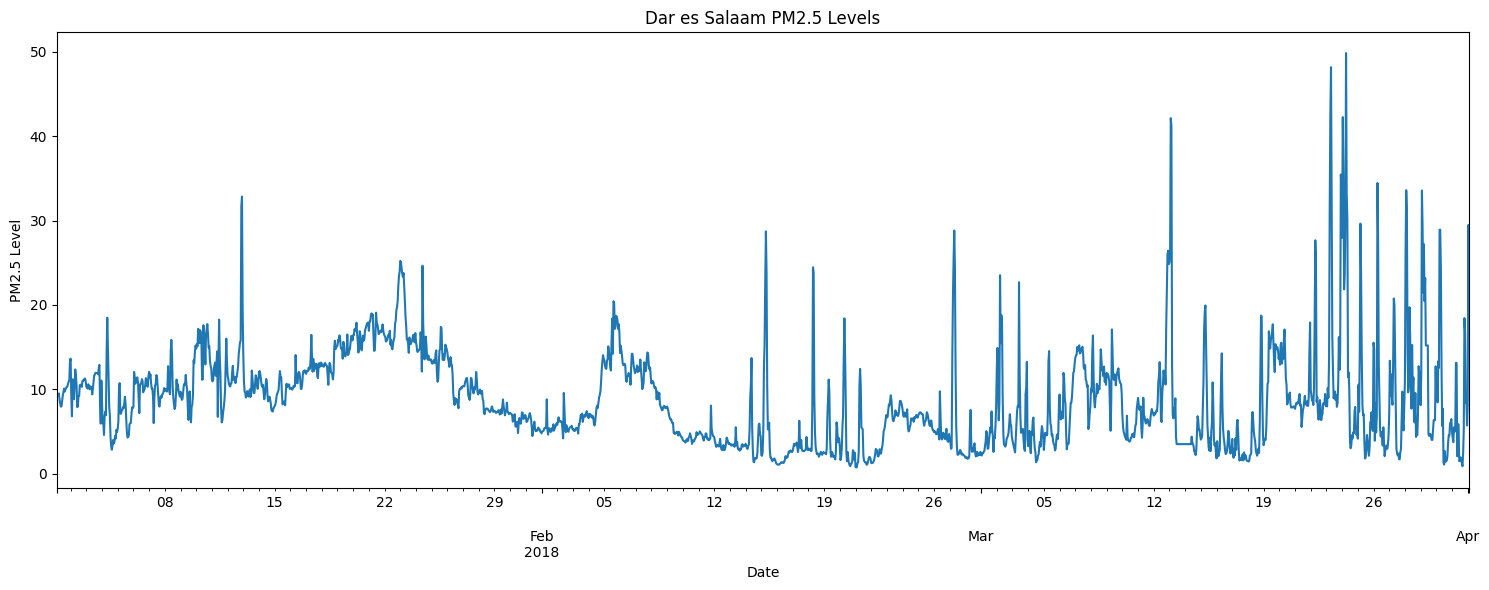

In [ ]:
fig, ax = plt.subplots(figsize=(15, 6))
df["P2"].plot(xlabel="Date", ylabel="PM2.5 Level", title="Dar es Salaam PM2.5 Levels", ax=ax)
plt.tight_layout()
plt.show()

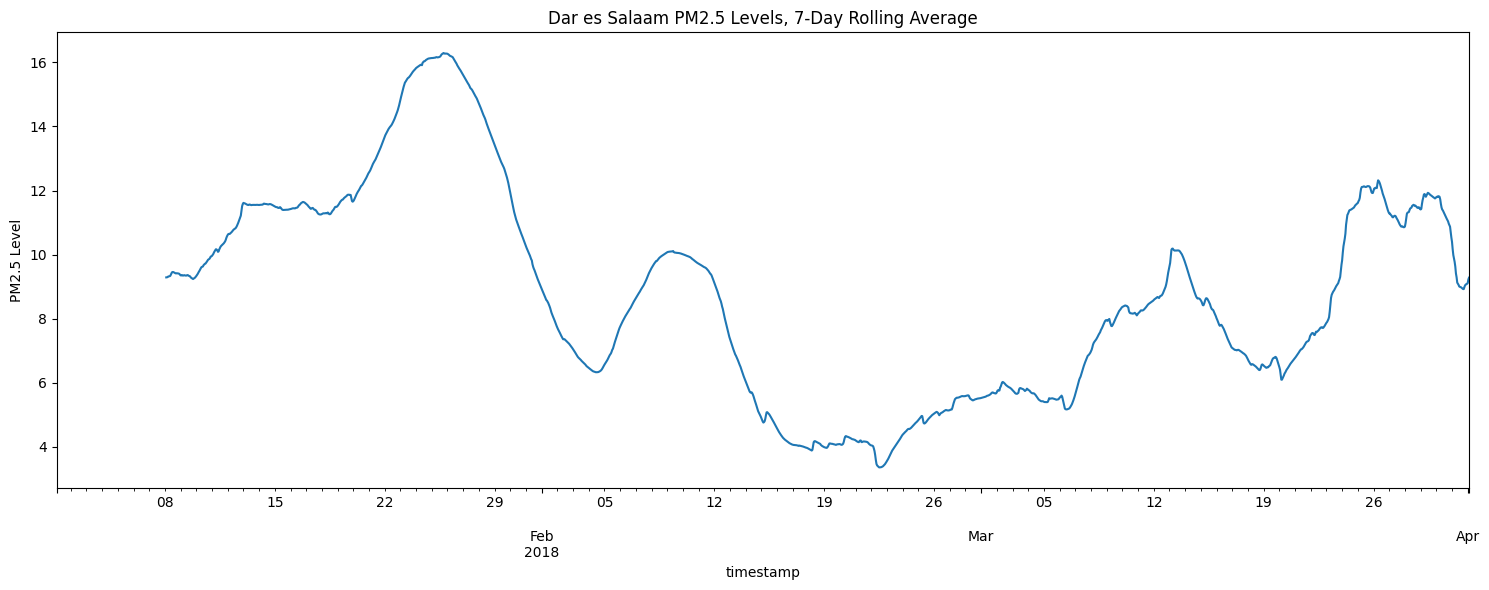

In [ ]:
# Line plot 
fig, ax = plt.subplots(figsize=(15, 6))
df["P2"].rolling(168).mean().plot(ax=ax, ylabel="PM2.5 Level", title= "Dar es Salaam PM2.5 Levels, 7-Day Rolling Average")
plt.tight_layout()
plt.show()

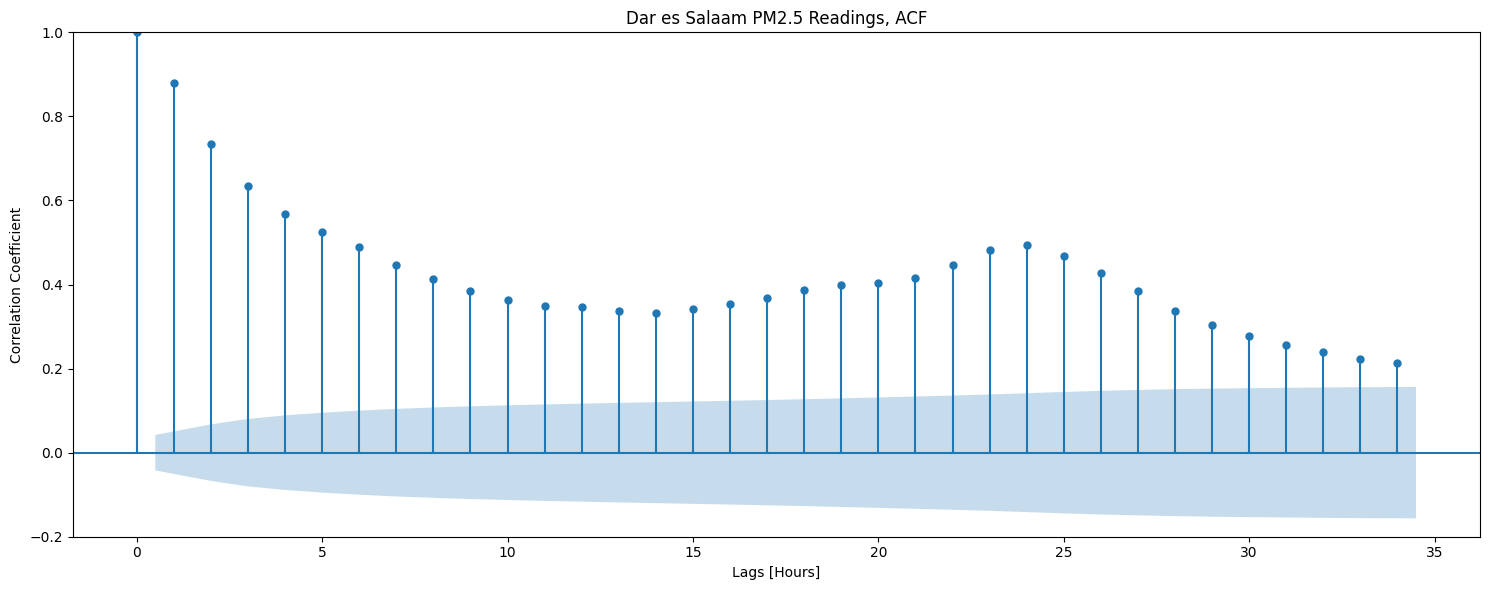

In [ ]:
# ACF Plot
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
fig, ax = plt.subplots(figsize=(15, 6))
plot_acf(df, ax=ax)
ax.set_ylim(bottom= -0.2)
plt.xlabel("Lags [Hours]")
plt.ylabel("Correlation Coefficient")
plt.title("Dar es Salaam PM2.5 Readings, ACF")
plt.tight_layout()
plt.show()

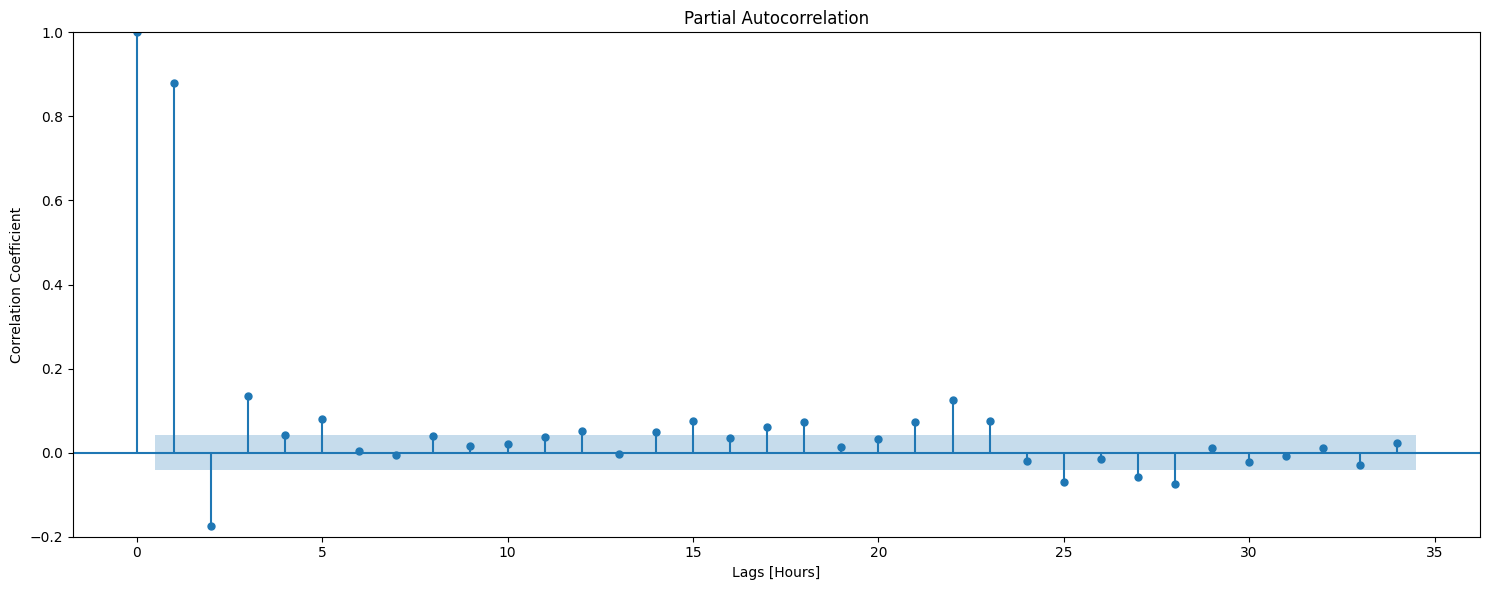

In [ ]:
# PACF Plot
fig, ax = plt.subplots(figsize=(15, 6))
plot_pacf(df, ax=ax)
ax.set_ylim(bottom= -0.2)
plt.xlabel("Lags [Hours]")
plt.ylabel("Correlation Coefficient")
plt.tight_layout()
plt.show()

In [ ]:
# Train-Test Split
df = df["P2"].resample("h").mean().ffill() # make y as series for splitting

cutoff_test = int(len (df) * 0.9)

y_train = df[:cutoff_test]
y_test = df[cutoff_test:]

print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

y_train shape: (1944,)
y_test shape: (216,)


In [ ]:
# Basline
from sklearn.metrics import mean_absolute_error

In [ ]:
y_train_mean = y_train.mean()
y_pred_baseline = [y_train_mean] * len(y_train)
mae_baseline = mean_absolute_error(y_train, y_pred_baseline)

print("Mean P2 Reading:", round(y_train_mean, 2))
print("Baseline MAE:", round(mae_baseline, 2))

Mean P2 Reading: 8.57
Baseline MAE: 4.05


In [ ]:
# Instantiate  AutoReg
from statsmodels.tsa.ar_model import AutoReg

In [ ]:
model = AutoReg(y_train, lags=30).fit()

In [ ]:
model.predict().isnull().sum()

np.int64(30)

In [ ]:
y_pred = model.predict().dropna()
training_mae = mean_absolute_error(y_train.iloc[30:], y_pred)
print("Training MAE:", round(training_mae, 2))

Training MAE: 1.02


In [ ]:
# Create range to test different lags
p_params = range(1, 31)

# Create empty list to hold mean absolute error scores
maes = []

# Iterate through all values of p in `p_params`
for p in p_params:
    # Build model
    model = AutoReg(y_train, lags=p).fit()

    # Make predictions on training data, dropping null values caused by lag
    y_pred = model.predict().dropna()

    # Calculate mean absolute error for training data vs predictions
    mae = mean_absolute_error(y_train.iloc[p:], y_pred)

    # Append `mae` to list `maes`
    maes.append(mae)

# Put list `maes` into Series with index `p_params`
mae_series = pd.Series(maes, name="mae", index=p_params)

# Inspect head of Series
mae_series.head()

1    1.059376
2    1.045182
3    1.032489
4    1.032147
5    1.031022
Name: mae, dtype: float64

In [ ]:
# Determine best p
best_p = mae_series.idxmin()
best_model = AutoReg(y_train, lags=best_p).fit()
best_mae = mae_series.min()
print(f"Best p: {best_p}, with MAE: {round(best_mae, 2)}")

Best p: 26, with MAE: 1.01


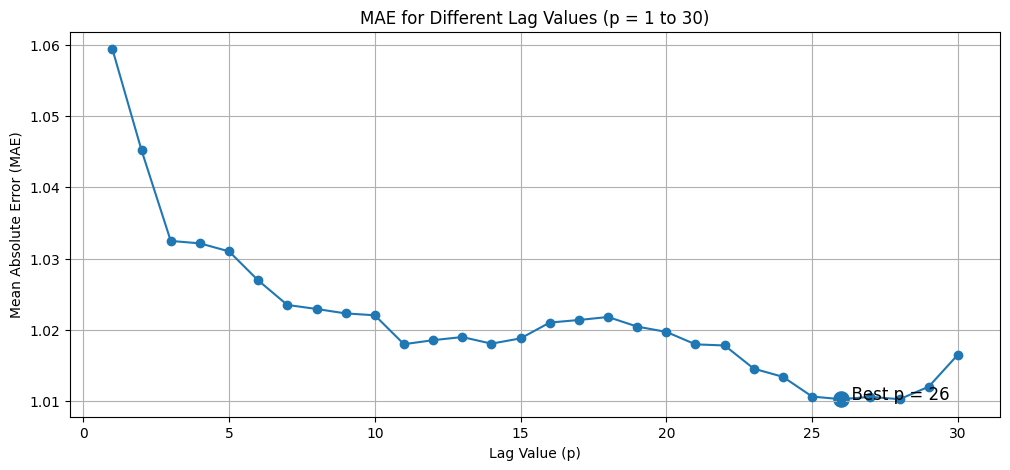

In [ ]:
# Personal review
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 5))
plt.plot(mae_series.index, mae_series.values, marker='o')
plt.title("MAE for Different Lag Values (p = 1 to 30)")
plt.xlabel("Lag Value (p)")
plt.ylabel("Mean Absolute Error (MAE)")

# Highlight the best lag
best_p = mae_series.idxmin()
best_mae = mae_series.min()

plt.scatter(best_p, best_mae, s=120)
plt.text(best_p, best_mae, f"  Best p = {best_p}", fontsize=12)

plt.grid(True)
plt.show()

In [ ]:
# Residual Analysis
y_train_resid = y_train - best_model.predict().dropna()
y_train_resid.name = "residuals"
y_train_resid.head()

timestamp
2018-01-01 03:00:00+03:00   NaN
2018-01-01 04:00:00+03:00   NaN
2018-01-01 05:00:00+03:00   NaN
2018-01-01 06:00:00+03:00   NaN
2018-01-01 07:00:00+03:00   NaN
Freq: h, Name: residuals, dtype: float64

In [ ]:
# Residual Analysis
y_train_resid = y_train - best_model.predict().dropna()
y_train_resid.name = "residuals"
y_train_resid

timestamp
2018-01-01 03:00:00+03:00         NaN
2018-01-01 04:00:00+03:00         NaN
2018-01-01 05:00:00+03:00         NaN
2018-01-01 06:00:00+03:00         NaN
2018-01-01 07:00:00+03:00         NaN
                               ...   
2018-03-22 22:00:00+03:00   -0.157974
2018-03-22 23:00:00+03:00   -1.114870
2018-03-23 00:00:00+03:00    0.495103
2018-03-23 01:00:00+03:00    0.030638
2018-03-23 02:00:00+03:00    2.401650
Freq: h, Name: residuals, Length: 1944, dtype: float64

In [ ]:
# Get model fitted values (in-sample predictions)
fitted = best_model.fittedvalues

# Align y_train to match prediction index
y_aligned = y_train.loc[fitted.index]

# Compute residuals
y_train_resid = y_aligned - fitted
y_train_resid.name = "residuals"

y_train_resid

timestamp
2018-01-02 05:00:00+03:00   -0.412913
2018-01-02 06:00:00+03:00    1.484934
2018-01-02 07:00:00+03:00    1.672359
2018-01-02 08:00:00+03:00   -0.368030
2018-01-02 09:00:00+03:00   -0.536868
                               ...   
2018-03-22 22:00:00+03:00   -0.157974
2018-03-22 23:00:00+03:00   -1.114870
2018-03-23 00:00:00+03:00    0.495103
2018-03-23 01:00:00+03:00    0.030638
2018-03-23 02:00:00+03:00    2.401650
Freq: h, Name: residuals, Length: 1918, dtype: float64

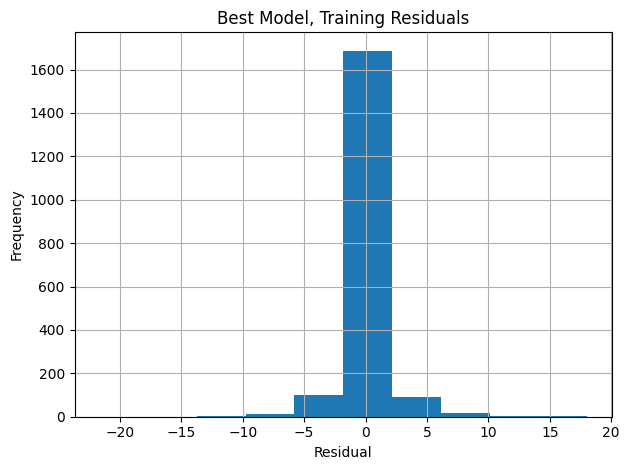

In [ ]:
# Residual Plots
fig, ax = plt.subplots()
y_train_resid.hist(ax=ax)
ax.set_title("Best Model, Training Residuals")
ax.set_xlabel("Residual")
ax.set_ylabel("Frequency")
plt.tight_layout()
plt.show()

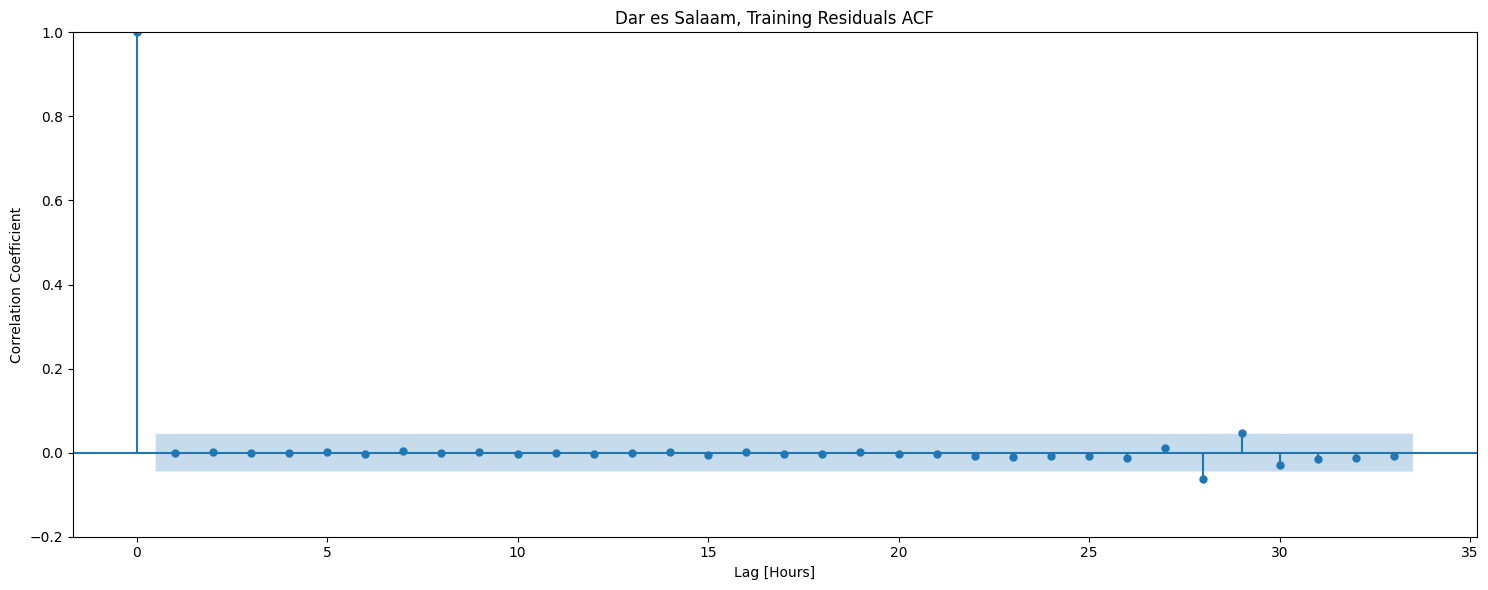

In [ ]:
# ACF Plot of Residuals
fig, ax = plt.subplots(figsize=(15, 6))
plot_acf(y_train_resid, ax=ax)
ax.set_ylim(bottom= -0.2)
plt.xlabel("Lag [Hours]")
plt.ylabel("Correlation Coefficient")
plt.title("Dar es Salaam, Training Residuals ACF")
plt.tight_layout()

In [ ]:
# Walk-Forward Validation
y_pred_wfv = pd.Series(dtype="float64")
history = y_train.copy()
for i in range(len(y_test)):
    model = AutoReg(history, lags=best_p).fit()
    next_pred = model.forecast()

    # Append prediction
    y_pred_wfv = pd.concat([y_pred_wfv, next_pred])

    # Append the actual next value from y_test
    history = pd.concat([history, y_test.loc[next_pred.index]])
        
y_pred_wfv.name = "prediction"
y_pred_wfv.index.name = "timestamp"
y_pred_wfv

<ipython-input-97-e9a44b0ff4e8>:9: FutureWarning: The behavior of array concatenation with empty entries is deprecated. In a future version, this will no longer exclude empty items when determining the result dtype. To retain the old behavior, exclude the empty entries before the concat operation.
  y_pred_wfv = pd.concat([y_pred_wfv, next_pred])


timestamp
2018-03-23 03:00:00+03:00    10.414744
2018-03-23 04:00:00+03:00     8.269589
2018-03-23 05:00:00+03:00    15.178677
2018-03-23 06:00:00+03:00    33.475398
2018-03-23 07:00:00+03:00    39.571363
                               ...    
2018-03-31 22:00:00+03:00     6.939370
2018-03-31 23:00:00+03:00     8.114680
2018-04-01 00:00:00+03:00     5.710798
2018-04-01 01:00:00+03:00     9.133960
2018-04-01 02:00:00+03:00    28.946615
Freq: h, Name: prediction, Length: 216, dtype: float64

In [ ]:
# Evaluate Walk-Forward Validation
test_mae = mean_absolute_error(y_test, y_pred_wfv)
print("Test MAE (walk forward validation):", round(test_mae, 2))

Test MAE (walk forward validation): 3.97


In [ ]:
# Communicate Results
import plotly.express as px

In [ ]:
df_pred_test = pd.DataFrame({"y_test": y_test, "y_pred_wfv": y_pred_wfv})

In [ ]:
df_pred_test =  pd.DataFrame({
    "y_test": y_test,
    "y_pred_wfv": y_pred_wfv
})
fig = px.line(df_pred_test)
fig.update_layout(
    title="Dar es Salaam, WFV Predictions",
    xaxis_title="Date",
    yaxis_title="PM2.5 Level",
)

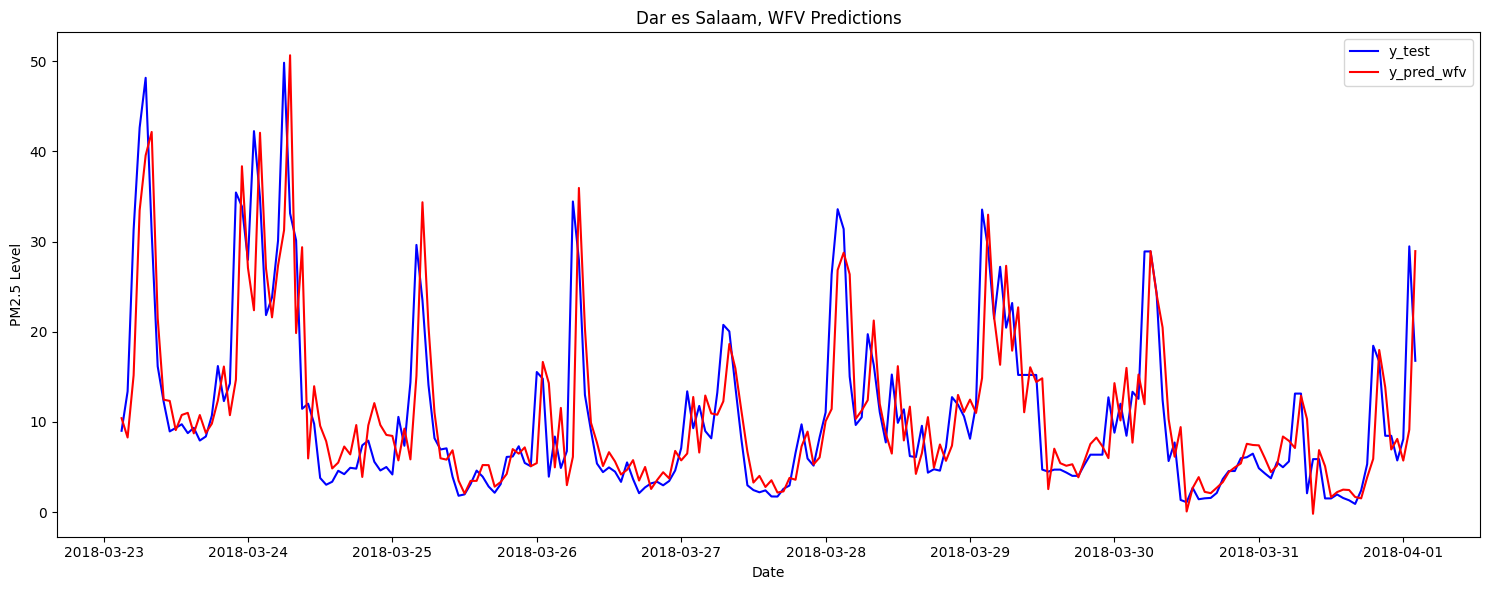

In [ ]:
# Create the figure and axis
fig, ax = plt.subplots(figsize=(15, 6))

# Plot the actual values
ax.plot(y_test.index, y_test.values, label="y_test", color="blue")

# Plot the predicted values
ax.plot(y_pred_wfv.index, y_pred_wfv.values, label="y_pred_wfv", color="red")

# Set title and axis labels
ax.set_title("Dar es Salaam, WFV Predictions")
ax.set_xlabel("Date")
ax.set_ylabel("PM2.5 Level")

# Show legend
ax.legend()

# Adjust layout to fit everything
plt.tight_layout()

# Show plot
plt.show()